# Avaliação dos melhores modelos




## 1. Imports e Configuração

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import shutil
from pathlib import Path
sys.path.append(os.path.join("..", "src"))
from preprocessing.data_setup import (
    MIQRDataset, 
    train_transforms, 
    train_transforms_strong, 
    val_transforms, 
    get_weighted_sampler     
)
from training.models import get_model
from training.train_wandb import TrainerWandb
from training.focal_loss import FocalLoss         
from training.early_stopping import EarlyStopping 
from evaluation.metrics import MetricsEvaluator
from evaluation.gradcam_utils import InterpretabilityTools, get_target_layers_for_model
from evaluation.noise_robustness import evaluate_robustness
#from training.hyperparameter_search import run_grid_search
from evaluation.ensemble import (                  
    get_predictions_with_tta, 
    get_ensemble_predictions, 
    load_models_from_checkpoints
)

import wandb
wandb.login()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device em uso:', device)
DATA_DIR = os.path.join("..", "data", "MIQR-CC-Dataset")
TRAIN_CSV = os.path.join(DATA_DIR, "splits", "train.csv")
VAL_CSV   = os.path.join(DATA_DIR, "splits", "val.csv")
TEST_CSV  = os.path.join(DATA_DIR, "splits", "test.csv")
CLASS_NAMES = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\tomas\_netrc.
wandb: Currently logged in as: laura-losa-ferreira (laura-losa-ferreira-universidade-do-minho) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device em uso: cuda


In [2]:
import random

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # para multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed global fixada para: {seed}")

# Executar logo no início
set_seed(42)


Seed global fixada para: 42


## 2. DataLoaders



In [3]:
# =====================================================================
# DATALOADERS MODULARES 
# =====================================================================
BATCH_SIZE = 32

dataset_teste  = MIQRDataset(TEST_CSV,  DATA_DIR, transform=val_transforms)

test_loader  = DataLoader(dataset_teste,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


print(f"Teste:     {len(dataset_teste)} imagens | {len(test_loader)} batches")


Teste:     231 imagens | 8 batches


## 4. Avaliação Final no Conjunto de Teste

Métricas obrigatórias: **F1-Score Macro**, **Matriz de Confusão**, **Curvas AUC-ROC**.

A avaliar densenet121 normal...

F1-Macro no Teste: 0.4877
AUC-ROC no Teste:  0.7837
               precision    recall  f1-score   support

Biliary_Leaks       0.00      0.00      0.00        19
    Lithiasis       0.66      0.74      0.70       109
    Stricture       0.65      0.71      0.68        58
       Normal       0.60      0.56      0.57        45

     accuracy                           0.64       231
    macro avg       0.48      0.50      0.49       231
 weighted avg       0.59      0.64      0.61       231



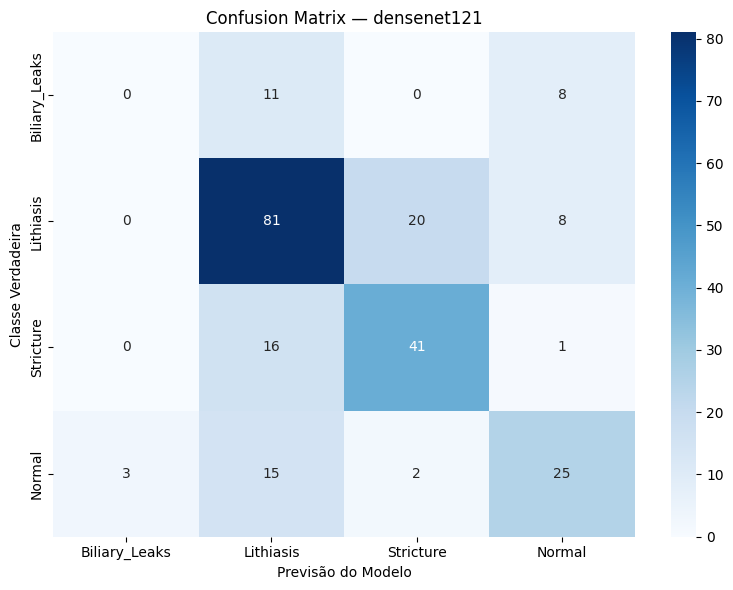

A avaliar efficientnet_v2_s normal...

F1-Macro no Teste: 0.4529
AUC-ROC no Teste:  0.7925
               precision    recall  f1-score   support

Biliary_Leaks       0.00      0.00      0.00        19
    Lithiasis       0.62      0.68      0.65       109
    Stricture       0.65      0.74      0.69        58
       Normal       0.48      0.47      0.47        45

     accuracy                           0.60       231
    macro avg       0.44      0.47      0.45       231
 weighted avg       0.55      0.60      0.57       231



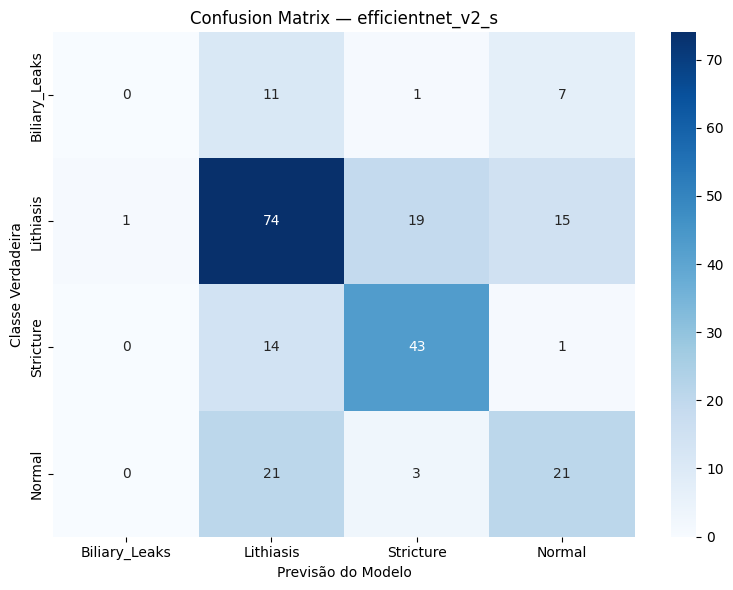

A avaliar vit_b_16 normal...

F1-Macro no Teste: 0.4262
AUC-ROC no Teste:  0.6801
               precision    recall  f1-score   support

Biliary_Leaks       0.00      0.00      0.00        19
    Lithiasis       0.60      0.69      0.64       109
    Stricture       0.52      0.66      0.58        58
       Normal       0.56      0.42      0.48        45

     accuracy                           0.57       231
    macro avg       0.42      0.44      0.43       231
 weighted avg       0.52      0.57      0.54       231



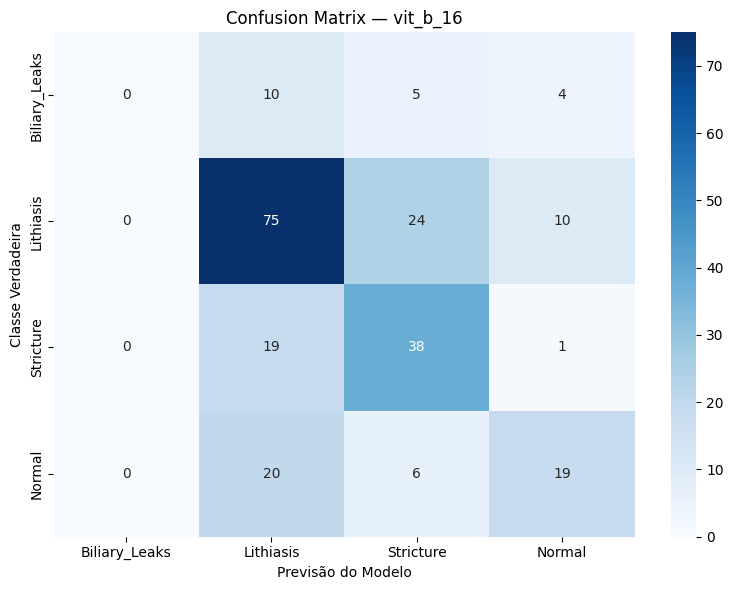

In [4]:
# =====================================================================
# AVALIAÇÃO DO MODELO
# =====================================================================
USE_TTA = False  # True para ativar TTA, False para avaliação padrão

# Procura todos os ficheiros .pth na pasta checkpoint dos melhores modelos
checkpoint_files = [str(caminho) for caminho in Path('checkpoints/best_models').glob('*.pth')]


if not checkpoint_files:
    print("Nenhum modelo encontrado na pasta 'checkpoints/best_models'.")
else:
    for checkpoint_path in sorted(checkpoint_files):
        # 1. Carregar modelo do melhor checkpoint
        
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
        model_name = checkpoint['model_name']
        model_eval = get_model(model_name, num_classes=4, feature_extracting=False)
        model_eval.load_state_dict(checkpoint['state_dict'])
        model_eval = model_eval.to(device)

        evaluator = MetricsEvaluator(CLASS_NAMES)

        # 2. Correr inferência
        if USE_TTA:
            print(f"A avaliar {model_name} no teste com Test-Time Augmentation (4 augmentações)...")
            test_probs, test_labels = get_predictions_with_tta(model_eval, test_loader, device, n_augments=4)
        else:
            print(f"A avaliar {model_name} normal...")
            all_probs, all_labels = [], []
            model_eval.eval()
            with torch.no_grad():
                for inputs, labels in test_loader:
                    outputs = model_eval(inputs.to(device))
                    probs = torch.softmax(outputs, dim=1)
                    all_probs.append(probs.cpu())
                    all_labels.append(labels.cpu())
            test_probs = torch.cat(all_probs)
            test_labels = torch.cat(all_labels)

        # 3. Mostrar métricas finais
        res = evaluator.evaluate(test_labels, test_probs)
        print(f"\nF1-Macro no Teste: {res['f1_macro']:.4f}")
        print(f"AUC-ROC no Teste:  {res['auc_roc']:.4f}")
        print(res['report'])

        # Mostrar e guardar Matriz de Confusão
        suffix = "_tta" if USE_TTA else "_normal"
        evaluator.plot_confusion_matrix(
            res['y_true'], 
            res['y_pred_labels'], 
            title=f"Confusion Matrix — {model_name}{' (TTA)' if USE_TTA else ''}",
            save_path=f"../outputs/best_models/confusion_matrix_best_model{model_name}{suffix}.png"
        )


A carregar o modelo densenet121 de checkpoints\best_models\densenet121.pth...
A carregar o modelo efficientnet_v2_s de checkpoints\best_models\efficientnet_v2_s.pth...
A carregar o modelo vit_b_16 de checkpoints\best_models\vit_b_16.pth...
A calcular previsões do Ensemble (densenet121, efficientnet_v2_s, vit_b_16)...

  RESULTADOS DO ENSEMBLE
F1-Score Macro: 0.4965
AUC-ROC:        0.7834

Relatório de Classificação:
               precision    recall  f1-score   support

Biliary_Leaks       0.00      0.00      0.00        19
    Lithiasis       0.64      0.78      0.70       109
    Stricture       0.70      0.74      0.72        58
       Normal       0.62      0.51      0.56        45

     accuracy                           0.65       231
    macro avg       0.49      0.51      0.50       231
 weighted avg       0.60      0.65      0.62       231



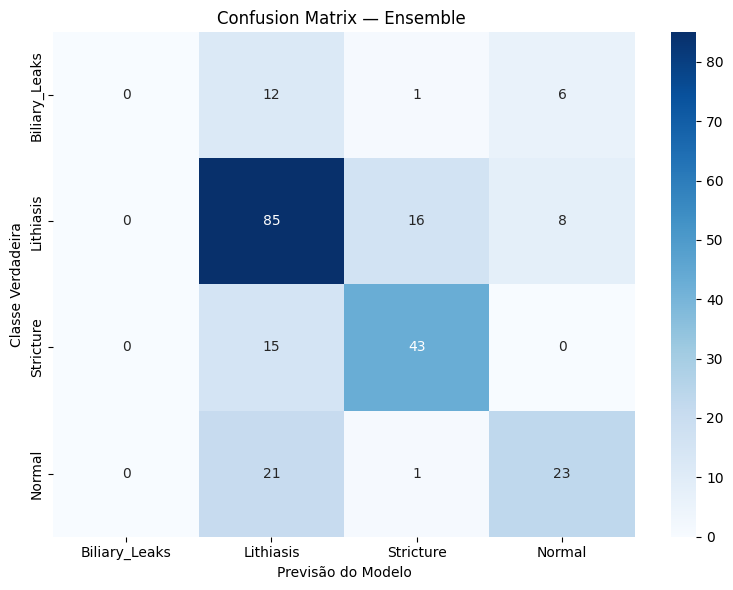

In [5]:
# =====================================================================
# AVALIAÇÃO DE ENSEMBLE DE MODELOS 
# =====================================================================

USE_TTA_IN_ENSEMBLE = False
modelos_ensemble=["densenet121","efficientnet_v2_s","vit_b_16"]
checkpoint_paths = [str(caminho) for caminho in Path('checkpoints/best_models').glob('*.pth')]


# 1. Carregar modelos
loaded_models = load_models_from_checkpoints(
    checkpoint_paths=checkpoint_paths,
    base_model_names=modelos_ensemble,
    num_classes=4,
    device=device
)

# 2. Obter probabilidades combinadas (média das previsões)
print(f"A calcular previsões do Ensemble ({', '.join(modelos_ensemble)})...")
ensemble_probs, test_labels = get_ensemble_predictions(
    models=loaded_models,
    dataloader=test_loader,
    device=device,
    use_tta=USE_TTA_IN_ENSEMBLE,
    n_augments=4
)

# 3. Avaliar
evaluator = MetricsEvaluator(CLASS_NAMES)
metrics_ens = evaluator.evaluate(test_labels, ensemble_probs)

print("\n" + "="*50)
print("  RESULTADOS DO ENSEMBLE")
print("="*50)
print(f"F1-Score Macro: {metrics_ens['f1_macro']:.4f}")
print(f"AUC-ROC:        {metrics_ens['auc_roc']:.4f}")
print("\nRelatório de Classificação:")
print(metrics_ens['report'])
print("="*50)

# 4. Desenhar e guardar gráficos do Ensemble
evaluator.plot_confusion_matrix(
    metrics_ens['y_true'], 
    metrics_ens['y_pred_labels'], 
    title="Confusion Matrix — Ensemble ",
    save_path="../outputs/best_models/confusion_matrix_ensemble.png"
)

evaluator.plot_roc_curves(
    metrics_ens['y_true'], 
    metrics_ens['probs'], 
    title="Curvas ROC — Ensemble",
    save_path="../outputs/best_models/roc_curves_ensemble.png"
)


## 5. Teste de Robustez ao Ruído

Avalia o modelo sob variações comuns em imagens de fluoroscopia:
ruído Gaussiano, variações de contraste e artefactos de pixels.

In [6]:
evaluator = MetricsEvaluator(CLASS_NAMES)
# 1. Encontrar todos os checkpoints válidos dos 4 modelos
checkpoint_files = [str(caminho) for caminho in Path('checkpoints/best_models').glob('*.pth')]
modelos_alvo=["densenet121","efficientnet_v2_s","vit_b_16"]

if not checkpoint_files:
    print("Nenhum modelo encontrado na pasta 'checkpoints/best_models'.")
else:
    for ckpt_path in sorted(checkpoint_files):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        nome_modelo = ckpt['model_name']
        nome_base = next((m for m in modelos_alvo if m in nome_modelo), nome_modelo)
        # Recriar o modelo e carregar os pesos
        temp_model = get_model(nome_base, num_classes=4, feature_extracting=False)
        temp_model.load_state_dict(ckpt['state_dict'])
        temp_model.to(device)
        temp_model.eval()
    
        print(f"\n--- Robustez: {nome_modelo} ---")
        robustness_results = evaluate_robustness(
            model=temp_model,
            test_loader=test_loader,
            evaluator=evaluator,
            device=device
        )
        



--- Robustez: densenet121 ---
Tipo de Ruído          F1-Macro   Degradação      AUC-ROC
------------------------------------------------------------
clean                    0.4877                    0.7837
gaussian                 0.2778      -0.2099       0.6031
contrast                 0.2725      -0.2151       0.5918
salt_pepper              0.4552      -0.0324       0.7363
combined                 0.2652      -0.2225       0.5756

--- Robustez: efficientnet_v2_s ---
Tipo de Ruído          F1-Macro   Degradação      AUC-ROC
------------------------------------------------------------
clean                    0.4529                    0.7925
gaussian                 0.2685      -0.1845       0.5371
contrast                 0.2297      -0.2233       0.5417
salt_pepper              0.1529      -0.3000       0.4639
combined                 0.1257      -0.3272       0.4861

--- Robustez: vit_b_16 ---
Tipo de Ruído          F1-Macro   Degradação      AUC-ROC
----------------------------

## 6. Interpretabilidade: Layer-CAM

 Gera heatmaps que mostram onde o modelo está a focar.

> Verifica se o foco está nos **ductos biliares** e não em artefactos externos.

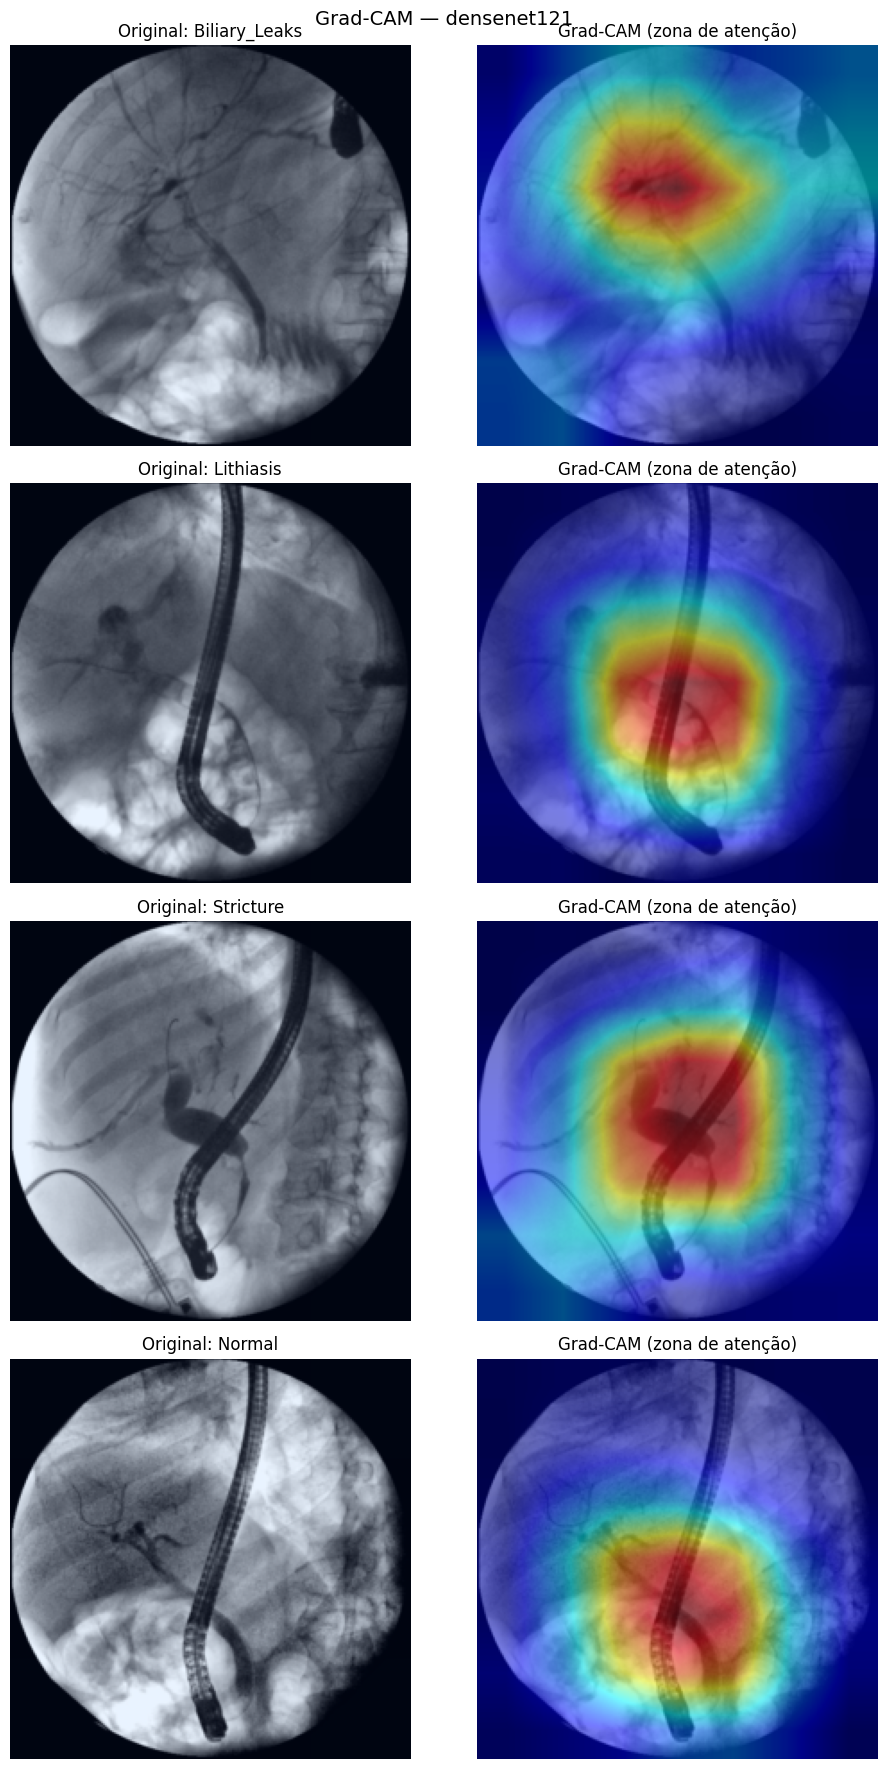

Heatmaps guardados em outputs/best_models/gradcam/


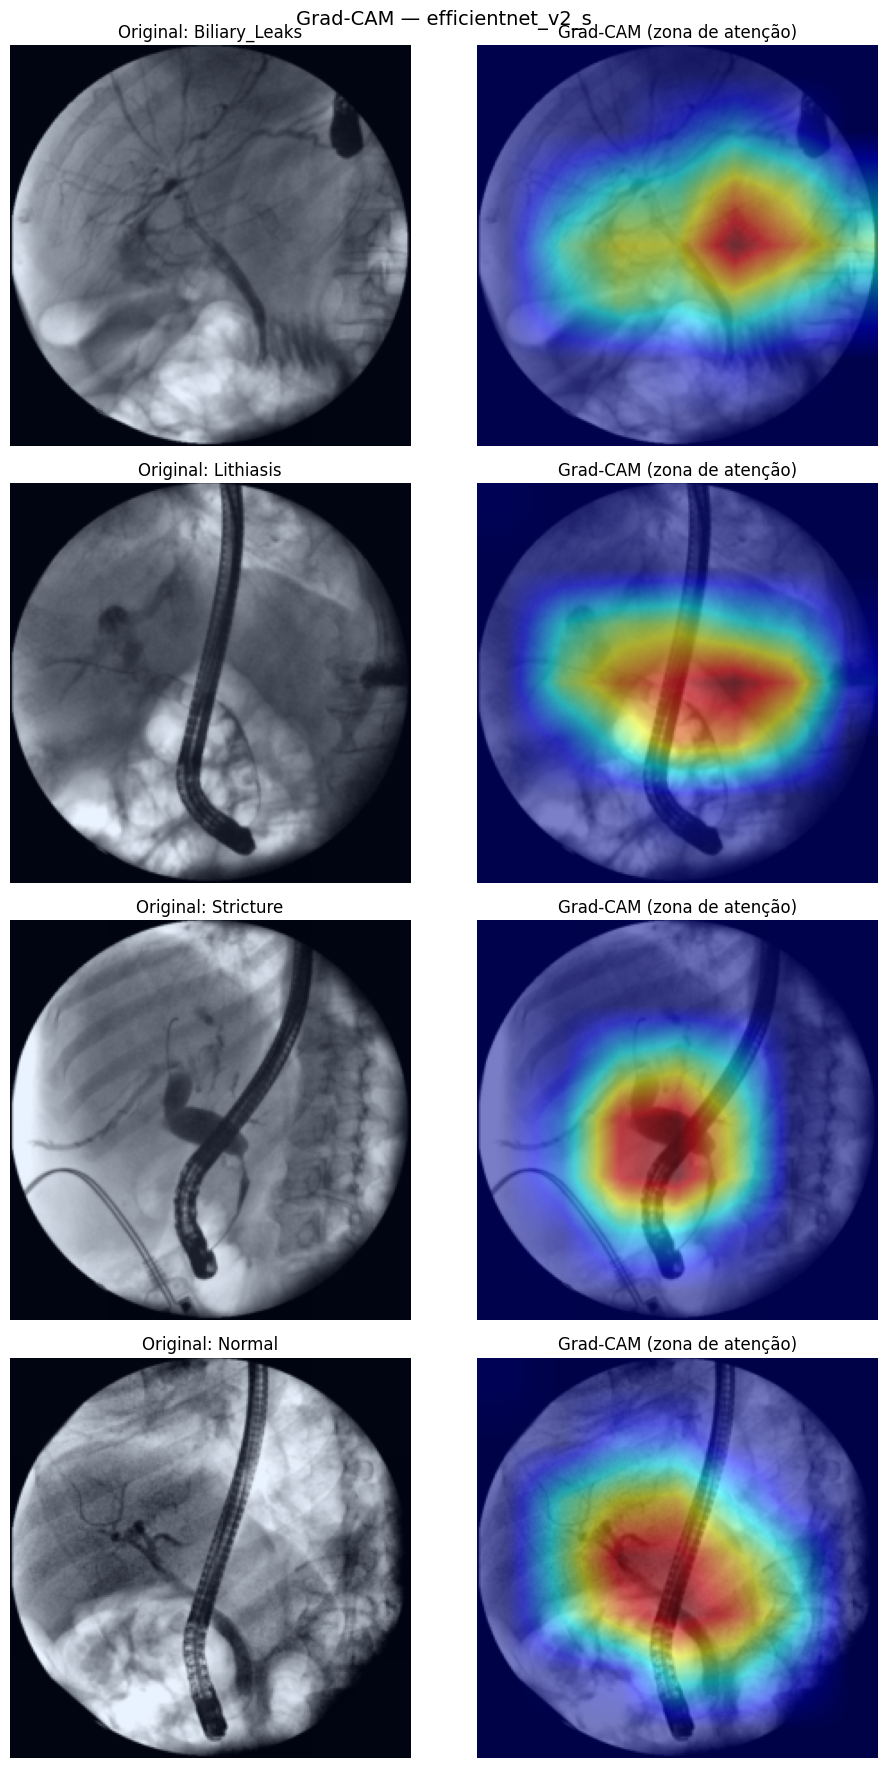

Heatmaps guardados em outputs/best_models/gradcam/


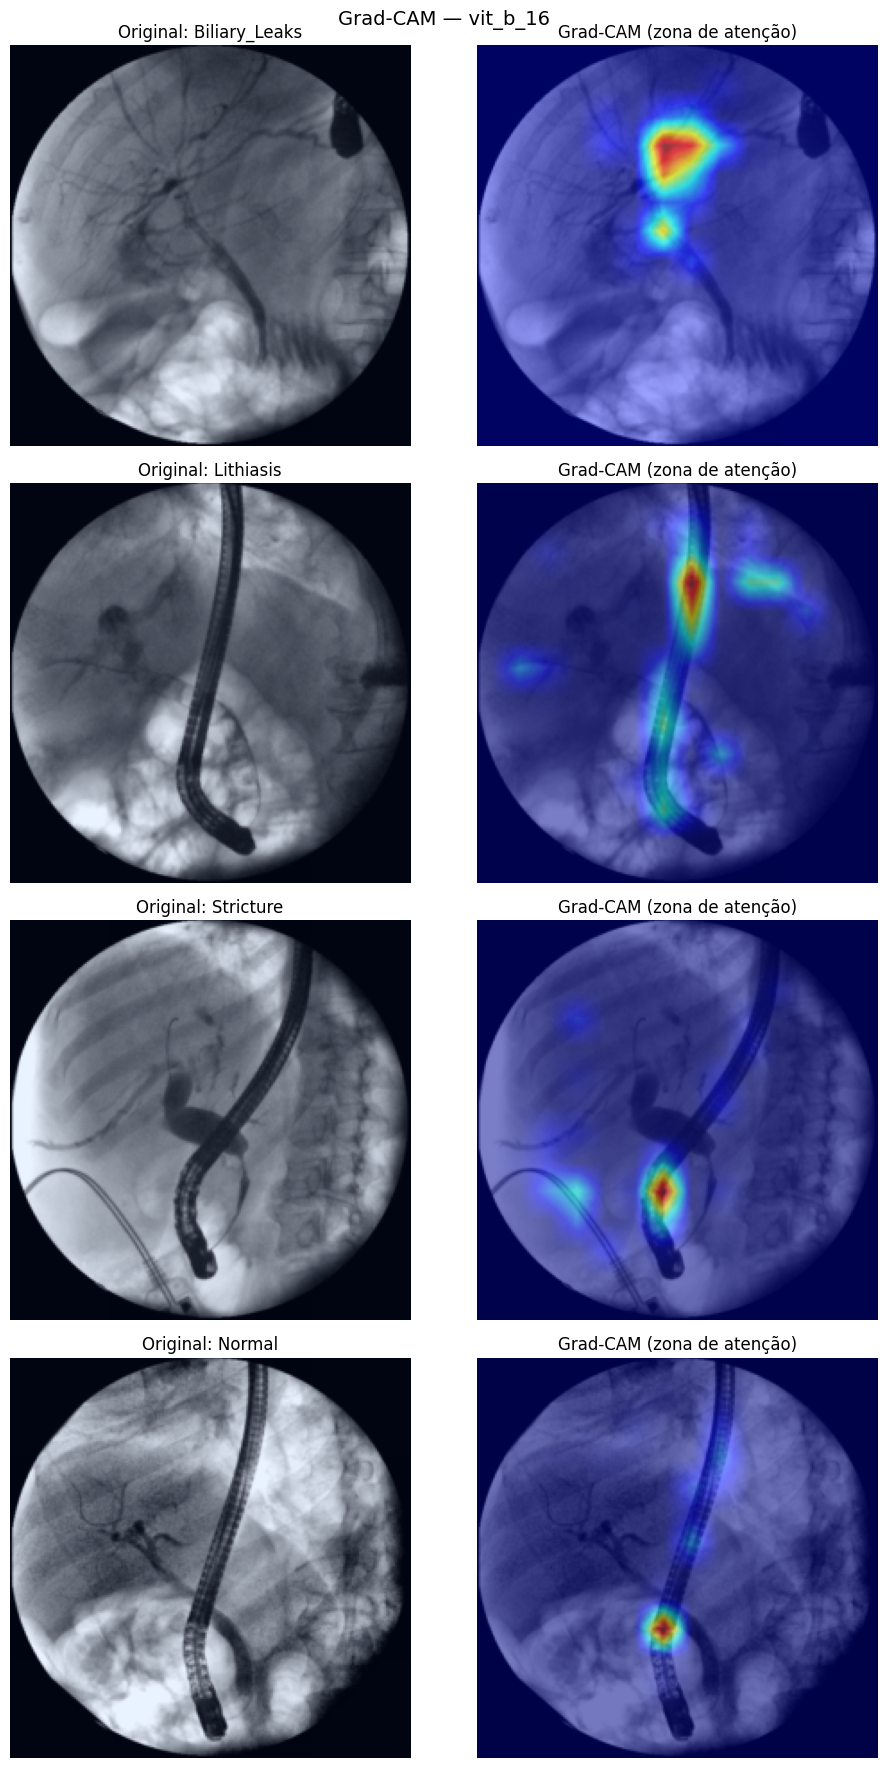

Heatmaps guardados em outputs/best_models/gradcam/


In [7]:
os.makedirs("../outputs/best_models/gradcam", exist_ok=True)
# Encontrar todos os checkpoints válidos dos 4 modelos
checkpoint_files = [str(caminho) for caminho in Path('checkpoints/best_models').glob('*.pth')]
modelos_alvo=["densenet121","efficientnet_v2_s","vit_b_16"]


if not checkpoint_files:
    print("Nenhum modelo encontrado na pasta 'checkpoints/best_models'.")
else:
    for ckpt_path in sorted(checkpoint_files):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        nome_modelo = ckpt['model_name']
        nome_base = next((m for m in modelos_alvo if m in nome_modelo), nome_modelo)
        # Recriar o modelo e carregar os pesos
        temp_model = get_model(nome_base, num_classes=4, feature_extracting=False)
        temp_model.load_state_dict(ckpt['state_dict'])
        temp_model.to(device)
        temp_model.eval()


        target_layers = get_target_layers_for_model(temp_model, nome_base)
        # Inicializar o interpretador usando LayerCAM em vez de Grad-CAM
        interpreter = InterpretabilityTools(temp_model, target_layers, method="layercam")


        indices_alvo = [38, 2, 0, 8]
        
        inputs_list = []
        labels_list = []
        for idx in indices_alvo:
            img_tensor, label = dataset_teste[idx]
            inputs_list.append(img_tensor)
            labels_list.append(label)
            
        inputs = torch.stack(inputs_list)
        labels = torch.stack(labels_list)

        fig, axes = plt.subplots(4, 2, figsize=(10, 18))
        fig.suptitle(f'Grad-CAM — {nome_modelo}', fontsize=14)

        for i in range(4):
            img_tensor = inputs[i:i+1].to(device)
            img_rgb = inputs[i].permute(1, 2, 0).cpu().numpy()
            img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)
            img_rgb = img_rgb.astype(np.float32)

            classe_verdadeira = labels[i].item()
            heatmap_img = interpreter.generate_gradcam(
                img_tensor, img_rgb,
                target_category=classe_verdadeira,
                save_path=f"../outputs/best_models/gradcam/gradcam_{nome_modelo}_{i}_{CLASS_NAMES[classe_verdadeira]}.png"
            )

            axes[i][0].imshow(img_rgb, cmap='gray')
            axes[i][0].set_title(f'Original: {CLASS_NAMES[classe_verdadeira]}')
            axes[i][0].axis('off')

            axes[i][1].imshow(heatmap_img)
            axes[i][1].set_title('Grad-CAM (zona de atenção)')
            axes[i][1].axis('off')

        plt.tight_layout()
        plt.savefig(f"../outputs/best_models/gradcam/gradcam_panel_{nome_modelo}.png", dpi=150)
        plt.show()
        print("Heatmaps guardados em outputs/best_models/gradcam/")